In [1]:
import lightkurve as lk
import matplotlib.pyplot as plt
import numpy as np

C:\Users\giahy\Downloads\anaconda\Lib\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [2]:
search = lk.search_lightcurve("Kepler-10", mission="Kepler")
print(search)

lc_raw = search[4].download()
print(f"\nData points: {len(lc_raw)}")
print(f"Time range: {lc_raw.time.value[0]:.1f} to {lc_raw.time.value[-1]:.1f} days")


SearchResult containing 50 data products.

 #       mission      year   author   exptime         target_name          distance
                                         s                                  arcsec 
--- ----------------- ---- ---------- ------- ---------------------------- --------
  0 Kepler Quarter 02 2009     Kepler      60                kplr011904151      0.0
  1 Kepler Quarter 03 2009     Kepler      60                kplr011904151      0.0
  2 Kepler Quarter 03 2009     Kepler      60                kplr011904151      0.0
  3 Kepler Quarter 03 2009     Kepler      60                kplr011904151      0.0
  4 Kepler Quarter 00 2009     Kepler    1800                kplr011904151      0.0
  5 Kepler Quarter 01 2009     Kepler    1800                kplr011904151      0.0
  6 Kepler Quarter 02 2009     Kepler    1800                kplr011904151      0.0
  7 Kepler Quarter 03 2009     Kepler    1800                kplr011904151      0.0
  8 Kepler Quarter 04 2010     Ke

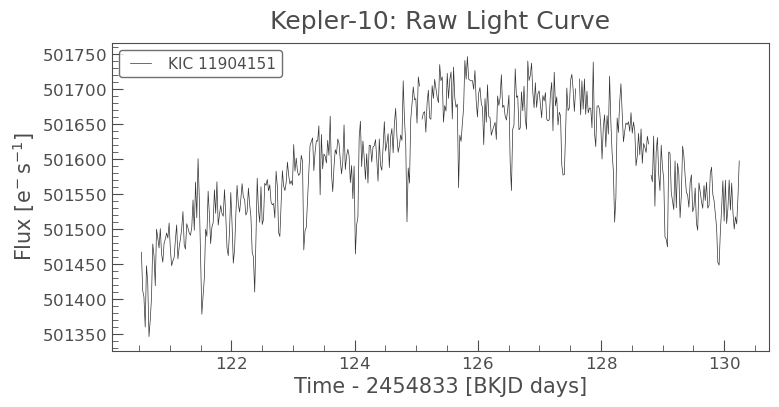

Plot saved to outputs/


In [3]:
lc_raw.plot(title="Kepler-10: Raw Light Curve")
plt.savefig("../outputs/01_raw_lightcurve.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to outputs/")

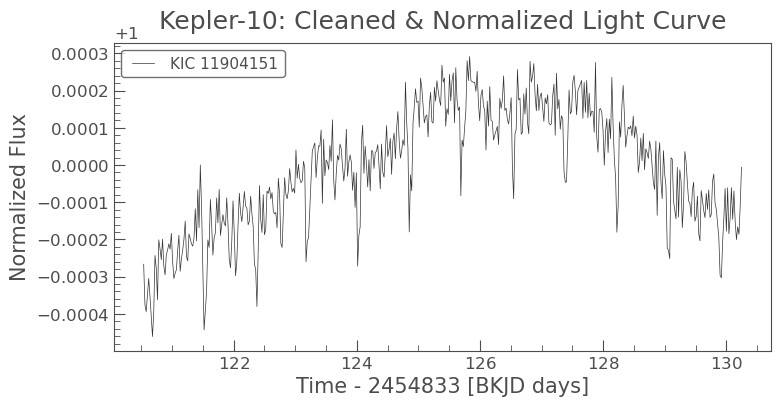

In [4]:
lc_clean = lc_raw.remove_nans().remove_outliers(sigma=3)

lc_normalized = lc_clean.normalize()

lc_normalized.plot(title="Kepler-10: Cleaned & Normalized Light Curve")
plt.savefig("../outputs/02_clean_lightcurve.png", dpi=150, bbox_inches='tight')
plt.show()

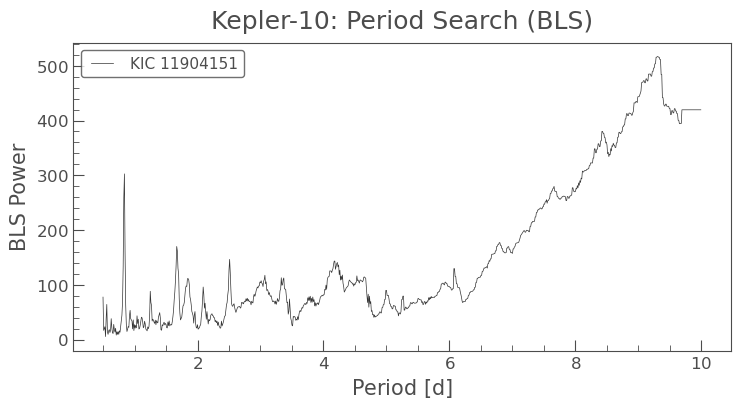


Most likely orbital period: 9.3000 d


In [5]:
from lightkurve import periodogram

pg = lc_normalized.to_periodogram(method="bls", 
                                   period=np.arange(0.5, 10, 0.01))
pg.plot(title="Kepler-10: Period Search (BLS)")
plt.savefig("../outputs/03_periodogram.png", dpi=150, bbox_inches='tight')
plt.show()

best_period = pg.period_at_max_power
print(f"\nMost likely orbital period: {best_period:.4f}")

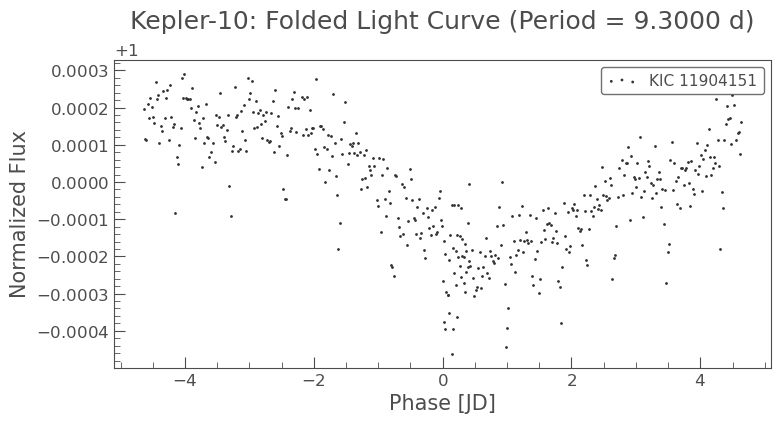

In [6]:
lc_folded = lc_normalized.fold(period=best_period)

lc_folded.scatter(title=f"Kepler-10: Folded Light Curve (Period = {best_period:.4f})")
plt.savefig("../outputs/04_folded_lightcurve.png", dpi=150, bbox_inches='tight')
plt.show()

In [7]:
print("=" * 50)
print("KEPLER-10 ANALYSIS SUMMARY")
print("=" * 50)
print(f"Data points analyzed: {len(lc_normalized)}")
print(f"Detected orbital period: {best_period:.4f}")

KEPLER-10 ANALYSIS SUMMARY
Data points analyzed: 467
Detected orbital period: 9.3000 d
